In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("/home/this/Documents/Piyush Jamdhade/Datasets-with-anaconda-and-jupyter-notebook/Social_Network_Ads.csv")

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.describe

<bound method NDFrame.describe of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [5]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.isnull()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
395,False,False,False,False,False
396,False,False,False,False,False
397,False,False,False,False,False
398,False,False,False,False,False


In [7]:
df.sum()

User ID                                                   6276615903
Gender             MaleMaleFemaleFemaleMaleMaleFemaleFemaleMaleFe...
Age                                                            15062
EstimatedSalary                                             27897000
Purchased                                                        143
dtype: object

In [8]:
df.shape

(400, 5)

In [9]:
df.shape[1]

5

In [10]:
df.shape[0]

400

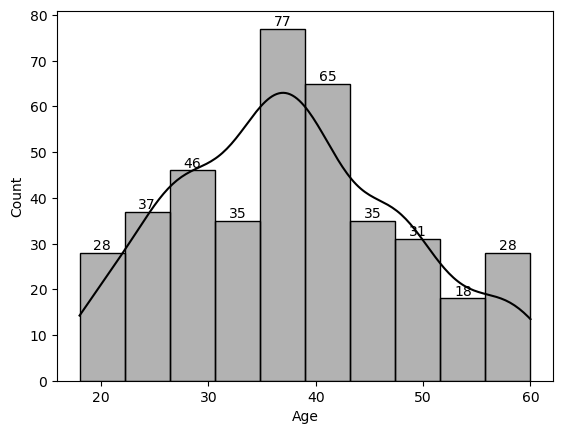

In [11]:
histplot = sns.histplot(df['Age'], kde=True, bins=10, color='black', alpha=0.3)
for i in histplot.containers:
    histplot.bar_label(i,)
plt.show()

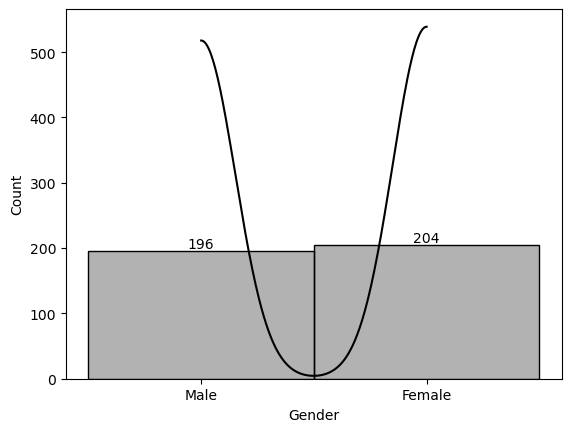

In [12]:
histplot = sns.histplot(df['Gender'], kde=True, bins=10, color='black', alpha=0.3)
for i in histplot.containers:
    histplot.bar_label(i,)
plt.show()

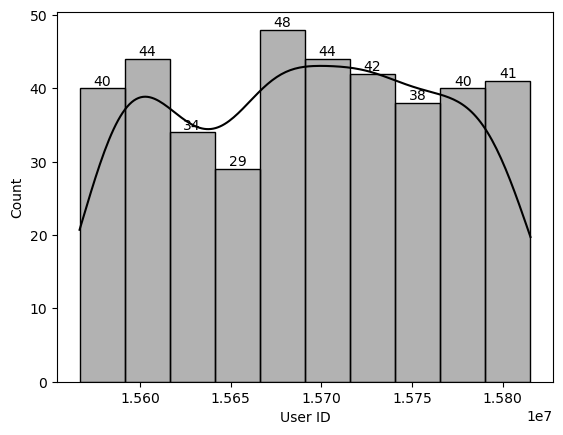

In [13]:
histplot = sns.histplot(df['User ID'], kde=True, bins=10, color='black', alpha=0.3)
for i in histplot.containers:
    histplot.bar_label(i,)
plt.show()

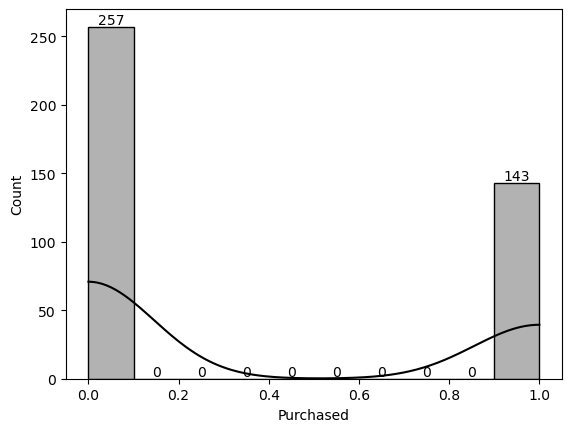

In [14]:
histplot = sns.histplot(df['Purchased'], kde=True, bins=10, color='black', alpha=0.3)
for i in histplot.containers:
    histplot.bar_label(i,)
plt.show()

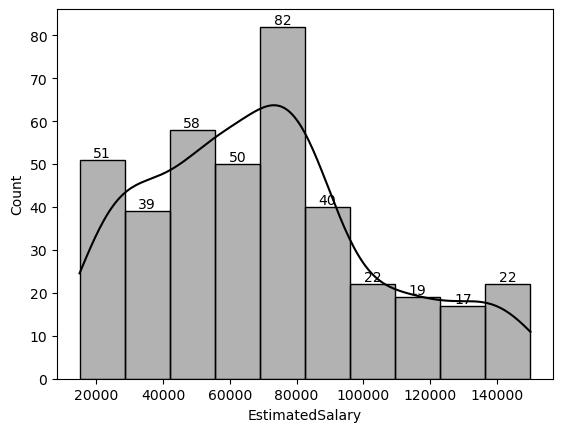

In [15]:
histplot = sns.histplot(df['EstimatedSalary'], kde=True, bins=10, color='black', alpha=0.3)
for i in histplot.containers:
    histplot.bar_label(i,)
plt.show()

In [16]:
df["Gender"].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [17]:
def gender_encoder(value):
    if (value == "Male"):
        return 1
    elif (value == "Female"):
        return 0
    else:
        return -1

In [18]:
df["Gender"] = df["Gender"].apply(gender_encoder)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [20]:
df.head(9)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
5,15728773,1,27,58000,0
6,15598044,0,27,84000,0
7,15694829,0,32,150000,1
8,15600575,1,25,33000,0


In [21]:
df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

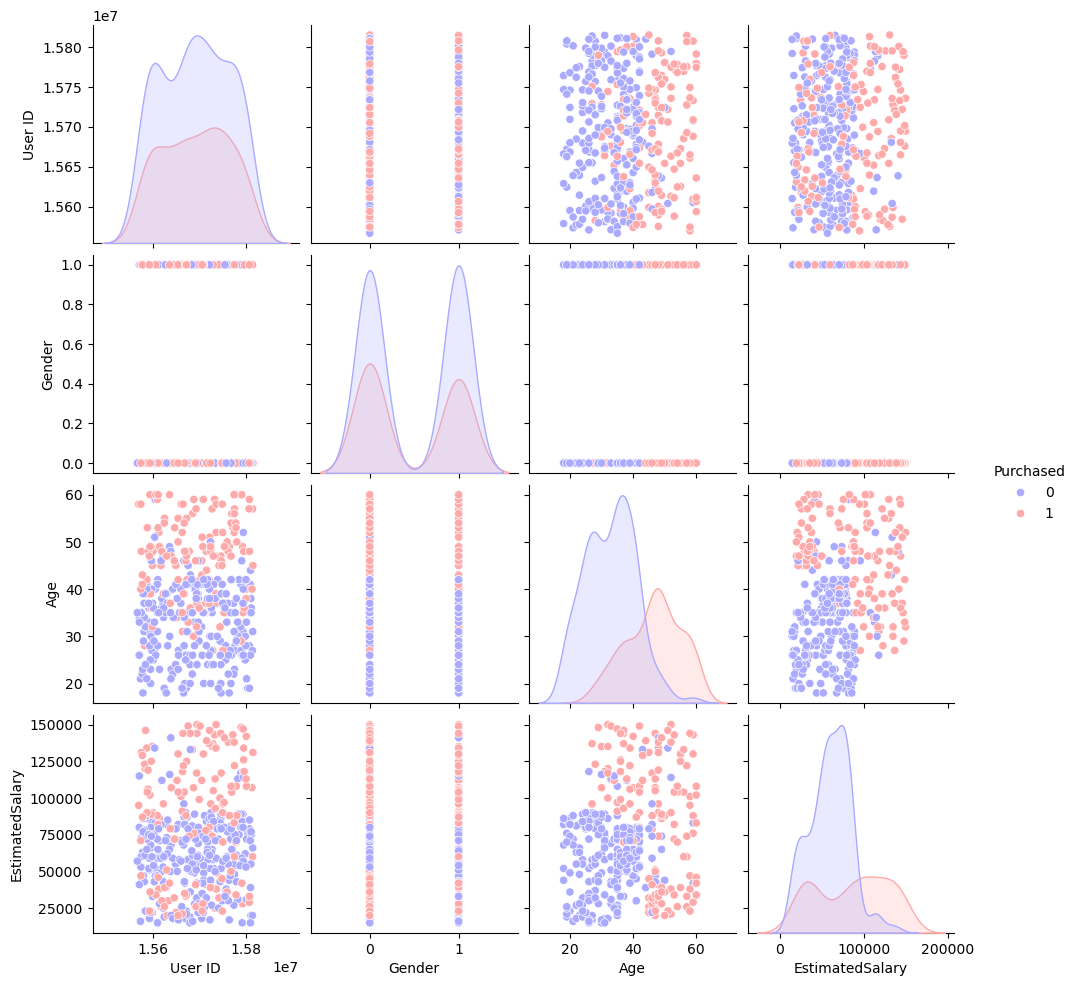

In [22]:
sns.pairplot(df,hue='Purchased',palette='bwr')
plt.show()

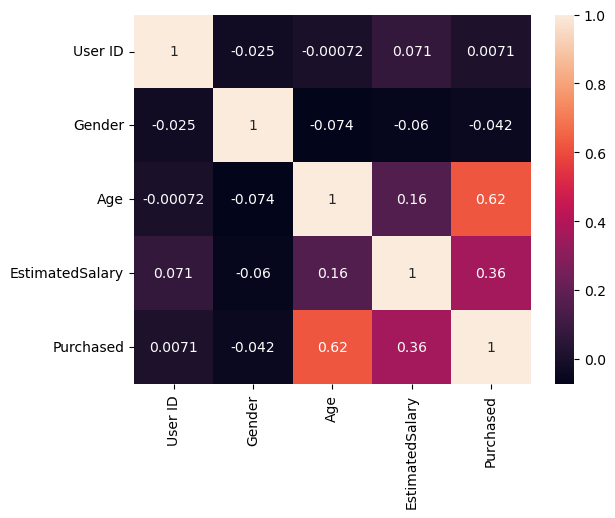

In [23]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [24]:
x = df[['User ID', "Gender", "Age", "EstimatedSalary"]]
y = df["Purchased"]

In [25]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((320, 4), (80, 4), (320,), (80,))

In [28]:
model = LogisticRegression()

In [29]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [31]:
model.score(x_train, y_train)

0.821875

In [32]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[50  2]
 [ 7 21]]


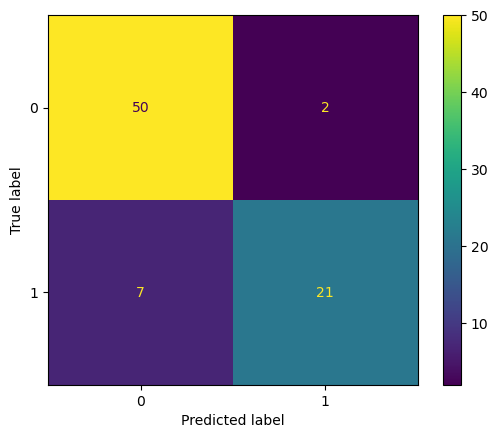

In [33]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [35]:
print(f"TN value is {cm[0][0]}")
print(f"FP value is {cm[0][1]}")
print(f"FN value is {cm[1][0]}")
print(f"TP value is {cm[1][1]}")

TN value is 50
FP value is 2
FN value is 7
TP value is 21


In [37]:
print(f"Accuracy score is {accuracy_score(y_test, y_pred)}")

Accuracy score is 0.8875


In [38]:
print(f"Error rate is {1-accuracy_score(y_test, y_pred)}")

Error rate is 0.11250000000000004


In [39]:
print(f"Precision score is {precision_score(y_test, y_pred)}")

Precision score is 0.9130434782608695


In [40]:
print(f"Recall score is {recall_score(y_test, y_pred)}")

Recall score is 0.75


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80

